In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/housing-prices-in-cdmx/housing_data_CDMX.csv
/kaggle/input/housing-prices-in-cdmx/housing_data_CDMX_v2.csv


In [2]:
df= pd.read_csv("/kaggle/input/housing-prices-in-cdmx/housing_data_CDMX_v2.csv")
df.head(10)

,property_type,places,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,lat,lon
0,apartment,MiguelHidalgo,"23.634501,-102.552788",5500000.0,MXN,5450245.50,289775.66,54.0,54.0,5366.215926,101851.85190,23.634501,-102.552788
1,house,Iztapalapa,"19.31033,-99.068557",1512000.0,MXN,1498321.97,79661.96,80.0,80.0,995.774500,18900.00000,19.310330,-99.068557
2,apartment,Tlalpan,"19.279771,-99.234597",926667.0,MXN,918284.00,48822.82,100.0,100.0,488.228200,9266.67000,19.279771,-99.234597
3,apartment,MiguelHidalgo,"23.634501,-102.552788",6410000.0,MXN,6352013.39,337720.36,135.0,135.0,2501.632296,47481.48148,23.634501,-102.552788
4,apartment,MiguelHidalgo,"19.432657,-99.177444",4416000.0,MXN,4376051.62,232663.51,87.0,87.0,2674.293218,50758.62069,19.432657,-99.177444
5,apartment,BenitoJuarez,"19.367025,-99.170349",3150000.0,MXN,3122244.47,166001.78,100.0,100.0,1660.017800,31500.00000,19.367025,-99.170349
6,house,AlvaroObregon,"19.340909,-99.22511",2086666.0,MXN,2067789.37,109939.09,205.0,205.0,536.288244,10178.85854,19.340909,-99.225110
7,house,GustavoAMadero,"19.509359,-99.093272",1600000.0,MXN,1585525.89,84298.37,144.0,144.0,585.405347,11111.11111,19.509359,-99.093272
8,house,MiguelHidalgo,"19.432901,-99.213075",4398100.0,MXN,4359347.04,231775.37,304.0,304.0,762.418980,14467.43421,19.432901,-99.213075
9,apartment,BenitoJuarez,"23.634501,-102.552788",1784569.0,MXN,1768425.20,94022.66,57.0,57.0,1649.520351,31308.22807,23.634501,-102.552788


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18234 entries, 0 to 18233
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   property_type               18234 non-null  object 
 1   places                      18234 non-null  object 
 2   lat-lon                     18234 non-null  object 
 3   price                       18234 non-null  float64
 4   currency                    18234 non-null  object 
 5   price_aprox_local_currency  18234 non-null  float64
 6   price_aprox_usd             18234 non-null  float64
 7   surface_total_in_m2         18234 non-null  float64
 8   surface_covered_in_m2       18234 non-null  float64
 9   price_usd_per_m2            18234 non-null  float64
 10  price_per_m2                18234 non-null  float64
 11  lat                         18234 non-null  float64
 12  lon                         18234 non-null  float64
dtypes: float64(9), object(4)
memory

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,18234.0,3.603177e+06,5.481585e+06,7000.000000,1.055008e+06,2.000000e+06,4.000000e+06,2.337267e+08
price_aprox_local_currency,18234.0,5.085788e+06,9.618485e+06,109030.610000,1.111025e+06,2.269284e+06,4.711236e+06,3.364841e+08
price_aprox_usd,18234.0,2.703984e+05,5.113903e+05,5796.880000,5.907037e+04,1.206520e+05,2.504844e+05,1.789000e+07
surface_total_in_m2,18234.0,4.062464e+03,4.872699e+05,1.000000,6.700000e+01,9.500000e+01,1.950000e+02,6.574800e+07
surface_covered_in_m2,18234.0,4.039938e+03,4.872686e+05,1.000000,6.700000e+01,9.500000e+01,2.000000e+02,6.574800e+07
price_usd_per_m2,18234.0,1.503674e+03,2.123173e+03,0.000600,6.773976e+02,1.108178e+03,1.897980e+03,1.759177e+05
price_per_m2,18234.0,2.480409e+04,4.047341e+04,0.011377,1.157143e+04,1.882843e+04,3.273260e+04,3.338953e+06
lat,18234.0,1.946429e+01,5.897342e-01,19.185852,1.935329e+01,1.938979e+01,1.942862e+01,4.157749e+01
lon,18234.0,-9.922484e+01,4.704926e-01,-102.552788,-9.919541e+01,-9.916430e+01,-9.913581e+01,-9.048847e+01


In [5]:
df.drop(["lat-lon","currency", "price_aprox_local_currency", "price_per_m2", "price_aprox_local_currency", "price"], axis='columns', inplace=True)
df.head(5)

,property_type,places,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,lat,lon
0,apartment,MiguelHidalgo,289775.66,54.0,54.0,5366.215926,23.634501,-102.552788
1,house,Iztapalapa,79661.96,80.0,80.0,995.774500,19.310330,-99.068557
2,apartment,Tlalpan,48822.82,100.0,100.0,488.228200,19.279771,-99.234597
3,apartment,MiguelHidalgo,337720.36,135.0,135.0,2501.632296,23.634501,-102.552788
4,apartment,MiguelHidalgo,232663.51,87.0,87.0,2674.293218,19.432657,-99.177444


In [6]:
df=pd.get_dummies(df, columns=['places', 'property_type'],drop_first=True)
df.head()

,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,lat,lon,places_Azcapotzalco,places_BenitoJuarez,places_Coyoacan,places_Cuajimalpa,...,places_MagdalenaContreras,places_MiguelHidalgo,places_MilpaAlta,places_Tlahuac,places_Tlalpan,places_VenustianoCarranza,places_Xochimilco,property_type_apartment,property_type_house,property_type_store
0,289775.66,54.0,54.0,5366.215926,23.634501,-102.552788,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
1,79661.96,80.0,80.0,995.774500,19.310330,-99.068557,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,48822.82,100.0,100.0,488.228200,19.279771,-99.234597,False,False,False,False,...,False,False,False,False,True,False,False,True,False,False
3,337720.36,135.0,135.0,2501.632296,23.634501,-102.552788,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
4,232663.51,87.0,87.0,2674.293218,19.432657,-99.177444,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False


In [7]:
df= df.replace({True: 1, False:0})
df.head()

/tmp/ipykernel_13/2798790270.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df= df.replace({True: 1, False:0})


,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,lat,lon,places_Azcapotzalco,places_BenitoJuarez,places_Coyoacan,places_Cuajimalpa,...,places_MagdalenaContreras,places_MiguelHidalgo,places_MilpaAlta,places_Tlahuac,places_Tlalpan,places_VenustianoCarranza,places_Xochimilco,property_type_apartment,property_type_house,property_type_store
0,289775.66,54.0,54.0,5366.215926,23.634501,-102.552788,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
1,79661.96,80.0,80.0,995.774500,19.310330,-99.068557,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,48822.82,100.0,100.0,488.228200,19.279771,-99.234597,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
3,337720.36,135.0,135.0,2501.632296,23.634501,-102.552788,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
4,232663.51,87.0,87.0,2674.293218,19.432657,-99.177444,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0


In [8]:
df.shape

(18234, 24)

In [9]:
df.isnull().sum()

price_aprox_usd              0
surface_total_in_m2          0
surface_covered_in_m2        0
price_usd_per_m2             0
lat                          0
lon                          0
places_Azcapotzalco          0
places_BenitoJuarez          0
places_Coyoacan              0
places_Cuajimalpa            0
places_Cuauhtemoc            0
places_GustavoAMadero        0
places_Iztacalco             0
places_Iztapalapa            0
places_MagdalenaContreras    0
places_MiguelHidalgo         0
places_MilpaAlta             0
places_Tlahuac               0
places_Tlalpan               0
places_VenustianoCarranza    0
places_Xochimilco            0
property_type_apartment      0
property_type_house          0
property_type_store          0
dtype: int64

In [10]:
df.duplicated().sum()

2956

In [11]:
df.drop_duplicates(keep='first', inplace=True)

In [12]:
df.shape

(15278, 24)

In [13]:
from sklearn.model_selection import train_test_split

X= df.drop('price_aprox_usd', axis='columns')
y=df['price_aprox_usd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [15]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Support Vector Regressor": SVR(),
    "KNN Regressor": KNeighborsRegressor()
}

In [17]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred) * 100  # convert to percentage
    results[name] = round(r2, 2)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.108e+15, tolerance: 3.686e+11
  model = cd_fast.enet_coordinate_descent(


In [18]:
print("Model Accuracy (R² Score in %):")
for model, acc in results.items():
    print(f"{model}: {acc}%")

Model Accuracy (R² Score in %):
Linear Regression: 38.53%
Ridge Regression: 38.43%
Lasso Regression: 38.43%
Decision Tree: 90.05%
Random Forest: 95.18%
Gradient Boosting: 97.88%
Support Vector Regressor: -9.89%
KNN Regressor: 56.51%


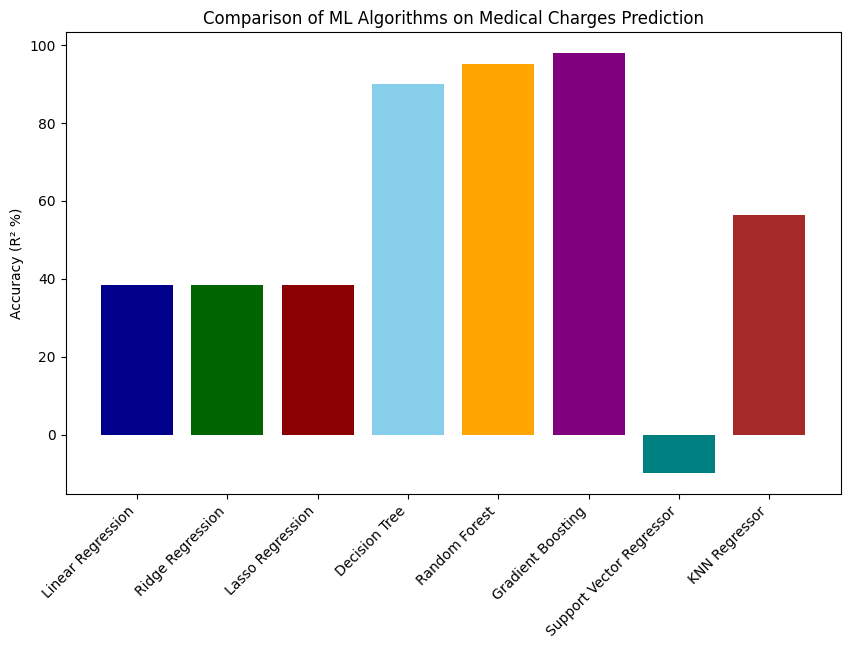

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(results.keys(), results.values(), color=['darkblue','darkgreen','darkred','skyblue','orange','purple','teal','brown'])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Accuracy (R² %)") 
plt.title("Comparison of ML Algorithms on Medical Charges Prediction")
plt.show()